<a href="https://colab.research.google.com/github/mehedihasan-cse/Open-Source/blob/main/GDELT_Code_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import torch
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Setup plot style
sns.set_theme(style='whitegrid')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/GDELT/df_scrape_final_save.csv')

In [5]:
df.head(5)

,GKGRECORDID,DATE,ArticleDate,Month,SourceCommonName,Host,RegisteredDomain,Headline,GDELT_AvgTone,GDELT_PositiveScore,...,V2Organizations,DocumentIdentifier,SourceGroup,UK_Relevance_Flag,Inflation_Relevance_Flag,Expectation_Language_Flag,UK_Strict_Flag,Core_Inflation_Flag,Extracted_Text,Word_Count
0,20250207124500-1063,20250207124500,2025-02-07,2025-02,sky.com,news.sky.com,sky.com,Billions for 'unproven' carbon capture technol...,0.228311,2.283105,...,"Public Accounts Committee,350",https://news.sky.com/story/billions-for-unprov...,Media_Journalistic_Commentary,1,1,1,True,True,"The government is spending £22bn on ""unproven""...",480
1,20260311150000-355,20260311150000,2026-03-11,2026-03,sky.com,news.sky.com,sky.com,Iran war: The outlook for your finances - whet...,-2.986162,1.019665,...,NaN,https://news.sky.com/story/bluesky-13517570,Media_Journalistic_Commentary,1,1,1,True,True,Donald Trump has raised hopes several times th...,1398
2,20240924111500-1205,20240924111500,2024-09-24,2024-09,sky.com,news.sky.com,sky.com,Brent crude prices rise amid Israeli air strik...,-4.297994,0.286533,...,NaN,https://news.sky.com/story/brent-crude-prices-...,Media_Journalistic_Commentary,1,1,1,True,True,The price of oil has risen sharply on the back...,775
3,20241022143000-1169,20241022143000,2024-10-22,2024-10,sky.com,news.sky.com,sky.com,UK economic forecast boosted by IMF,-1.418440,2.304965,...,"International Monetary Fund,31",https://news.sky.com/story/imf-upgrades-uk-by-...,Media_Journalistic_Commentary,1,1,1,True,True,The International Monetary Fund (IMF) has upgr...,641
4,20240618160000-616,20240618160000,2024-06-18,2024-06,sky.com,news.sky.com,sky.com,Money blog: Smoke machines deployed in Tesco; ...,1.111111,3.055556,...,"Cardiff University,1828",https://news.sky.com/story/money-blog-smoke-ma...,Media_Journalistic_Commentary,1,1,1,True,True,"What's abnormal about today's announcement, ac...",130


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11240 entries, 0 to 11239
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   GKGRECORDID                11240 non-null  object 
 1   DATE                       11240 non-null  int64  
 2   ArticleDate                11240 non-null  object 
 3   Month                      11240 non-null  object 
 4   SourceCommonName           11240 non-null  object 
 5   Host                       11240 non-null  object 
 6   RegisteredDomain           11240 non-null  object 
 7   Headline                   11240 non-null  object 
 8   GDELT_AvgTone              11240 non-null  float64
 9   GDELT_PositiveScore        11240 non-null  float64
 10  GDELT_NegativeScore        11240 non-null  float64
 11  GDELT_Polarity             11240 non-null  float64
 12  V2Tone                     11240 non-null  object 
 13  V2Themes                   11203 non-null  obj

In [7]:
df['ArticleDate'] = pd.to_datetime(df['ArticleDate'])

In [8]:
df = df.drop(columns=[
    'Amounts',
    'GKGRECORDID',
    'DATE',
    'Host',
    'UK_Strict_Flag',
    'Core_Inflation_Flag',
    'GCAM',
    'Dates',
    'ArticleDateTime',
    'Quotations',
    'RegisteredDomain',
    'UK_Relevance_Flag',
    'Inflation_Relevance_Flag',
    'Expectation_Language_Flag'
], errors='ignore')

In [9]:
df.isnull().sum()

,0
ArticleDate,0
Month,0
SourceCommonName,0
Headline,0
GDELT_AvgTone,0
GDELT_PositiveScore,0
GDELT_NegativeScore,0
GDELT_Polarity,0
V2Tone,0
V2Themes,37


In [12]:
df.dropna(subset=['Extracted_Text','V2Themes'], inplace=True)

In [13]:
df.isnull().sum()

,0
ArticleDate,0
Month,0
SourceCommonName,0
Headline,0
GDELT_AvgTone,0
GDELT_PositiveScore,0
GDELT_NegativeScore,0
GDELT_Polarity,0
V2Tone,0
V2Themes,0


In [15]:
highest_word_count_article = df.loc[df['Word_Count'].idxmax()]
print(f"Word Count: {highest_word_count_article['Word_Count']}")
print("Full Extracted Text:")
print(highest_word_count_article['Extracted_Text'])

Word Count: 8453
Full Extracted Text:
Watch the trailer for Civilisations: Rise and Fall

The moments when four ancient worlds faced disaster are brought to life in an epic new series exploring Rome, Egypt, the Aztecs and the samurai of Japan. Drawing on the beautiful art and artefacts left behind by these four cultures, now held in the British Museum, the series reveals the human stories at the heart of each crisis. A BBC Studios production for BBC Two and iPlayer, Civilisations: Rise and Fall begins on 24 November



CB Introduction from Suzy Klein, Head of BBC Arts & Classical Music TV “Bringing Civilisations back is a momentous occasion, and a real honour. Civilisation - as it was originally known - first aired in 1969, hosted by Kenneth Clark. This series became a defining piece of television, opening up a world of art and culture to audiences at home - and spectacularly in colour. “In 2018, Dame Mary Beard, David Olusoga, and Simon Schama took the helm and expanded the series’ sc

### Text Preprocessing
Defining functions to clean HTML tags, remove punctuation, and lemmatize text for analysis.

In [16]:
def remove_html_tags(text):
    """Removes HTML tags from a string using regex."""
    if not isinstance(text, str): return ""
    return re.sub(r'<.*?>', '', text)

# def preprocess_text(text):
#     """Cleans text: lowercases, removes punctuation/stopwords, and lemmatizes."""
#     if not isinstance(text, str): return ''
#     stop_words = set(stopwords.words('english'))
#     lemmatizer = WordNetLemmatizer()


    # text = text.lower().translate(str.maketrans('', '', string.punctuation))
    # words = text.split()
    # cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    # return ' '.join(cleaned_words)

In [17]:
# Apply the cleaning pipeline defined in the previous cell
df['Extracted_Text'] = df['Extracted_Text'].apply(remove_html_tags)#.apply(preprocess_text)
display(df[['Extracted_Text']].head())

,Extracted_Text
0,"The government is spending £22bn on ""unproven""..."
1,Donald Trump has raised hopes several times th...
2,The price of oil has risen sharply on the back...
3,The International Monetary Fund (IMF) has upgr...
4,"What's abnormal about today's announcement, ac..."


In [18]:
!pip install -q sentencepiece

import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification, AutoTokenizer, AutoModelForSequenceClassification

# Setup Device once
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Load FinBERT ---
fin_model_name = 'yiyanghkust/finbert-tone'
fin_tokenizer = BertTokenizer.from_pretrained(fin_model_name)
fin_model = BertForSequenceClassification.from_pretrained(fin_model_name).to(device)
fin_model.eval()

# --- Load InflaBERT ---
inf_model_name = 'MAPAi/InflaBERT'
inf_tokenizer = AutoTokenizer.from_pretrained(inf_model_name)
inf_model = AutoModelForSequenceClassification.from_pretrained(inf_model_name).to(device)
inf_model.eval()

def get_combined_sentiment(text, max_length=512):
    """Runs both models in one pass to save time/resources."""
    if not isinstance(text, str) or text.strip() == '':
        return 0.0, 0.0

    # Helper for chunked inference
    def process_chunks(model, tokenizer, is_inflabert=False):
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True,
                           max_length=max_length, return_overflowing_tokens=True, stride=0).to(device)

        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']

        scores = []
        for i in range(len(input_ids)):
            with torch.no_grad():
                outputs = model(input_ids=input_ids[i:i+1], attention_mask=attention_mask[i:i+1])

            logits = outputs.logits.cpu().numpy()[0]
            if is_inflabert and len(logits) == 1:
                scores.append(logits[0])
            else:
                probs = torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
                # Logic: Positive - Negative
                scores.append(probs[1] - probs[2])
        return np.mean(scores) if scores else 0.0

    fin_score = process_chunks(fin_model, fin_tokenizer)
    inf_score = process_chunks(inf_model, inf_tokenizer, is_inflabert=True)

    return fin_score, inf_score

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [19]:
import time

# We use a subset or the whole df. To run on the whole df:
print(f"Starting sentiment analysis for {len(df)} articles...")
start_time = time.time()

# Apply the combined function
# We use zip(*...) to unpack the tuple returned by the function into two columns
results = df['Extracted_Text'].apply(lambda x: get_combined_sentiment(x))
df['FinBERT_Combined'], df['InflaBERT_Combined'] = zip(*results)

end_time = time.time()
print(f"Finished! Total time: {(end_time - start_time) / 60:.2f} minutes.")

# Display the results
display(df[['ArticleDate', 'FinBERT_Combined', 'InflaBERT_Combined']].head())

Starting sentiment analysis for 10886 articles...
Finished! Total time: 25.58 minutes.


,ArticleDate,FinBERT_Combined,InflaBERT_Combined
0,2025-02-07,-0.016926,0.443672
1,2026-03-11,-0.145299,-0.490536
2,2024-09-24,-0.525095,-0.506862
3,2024-10-22,0.002362,0.000074
4,2024-06-18,0.620491,-0.144525


### Sentiment Analysis (FinBERT)
Calculating average sentiment scores for articles by processing text in chunks.

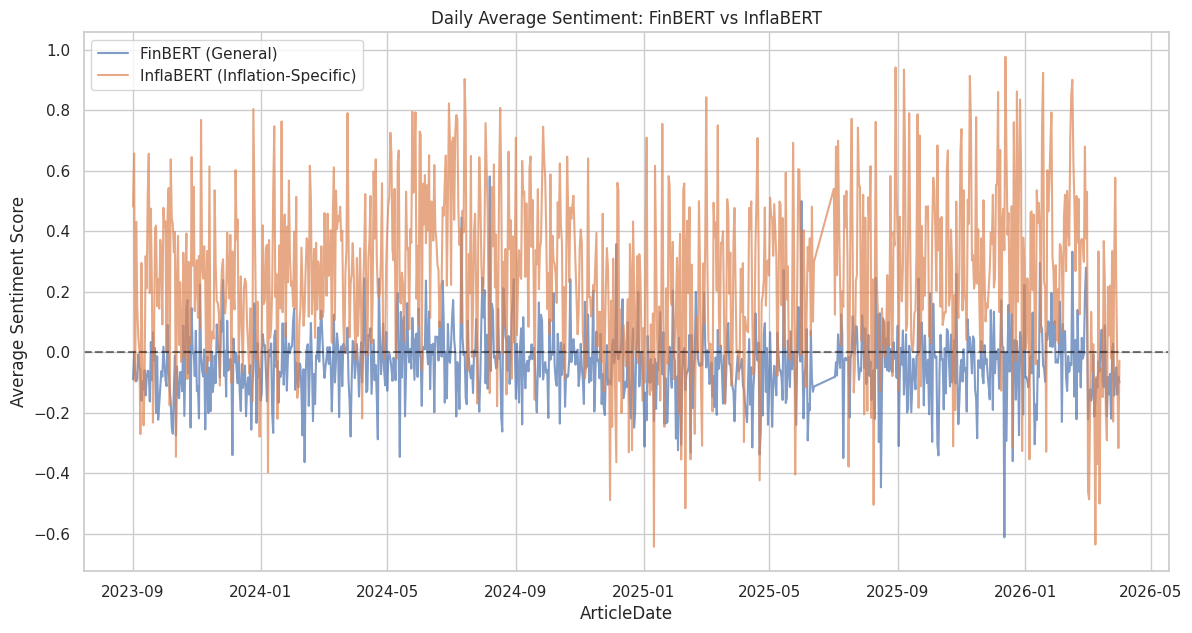

FinBERT Sentiment Distribution:
FinBERT_Label
Neutral     5715
Negative    3162
Positive    2009
Name: count, dtype: int64

InflaBERT Sentiment Distribution:
InflaBERT_Label
Positive    6216
Negative    3367
Neutral     1303
Name: count, dtype: int64


In [20]:
def categorize_score(score):
    if score > 0.05: return 'Positive'
    if score < -0.05: return 'Negative'
    return 'Neutral'

# Create labels for both models
df['FinBERT_Label'] = df['FinBERT_Combined'].apply(categorize_score)
df['InflaBERT_Label'] = df['InflaBERT_Combined'].apply(categorize_score)

# Calculate daily averages for both
daily_sentiment = df.groupby('ArticleDate')[['FinBERT_Combined', 'InflaBERT_Combined']].mean().reset_index()

# Plotting both
plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sentiment, x='ArticleDate', y='FinBERT_Combined', label='FinBERT (General)', alpha=0.7)
sns.lineplot(data=daily_sentiment, x='ArticleDate', y='InflaBERT_Combined', label='InflaBERT (Inflation-Specific)', alpha=0.7)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Daily Average Sentiment: FinBERT vs InflaBERT')
plt.ylabel('Average Sentiment Score')
plt.legend()
plt.show()

# Display summary distribution
print("FinBERT Sentiment Distribution:")
print(df['FinBERT_Label'].value_counts())
print("\nInflaBERT Sentiment Distribution:")
print(df['InflaBERT_Label'].value_counts())

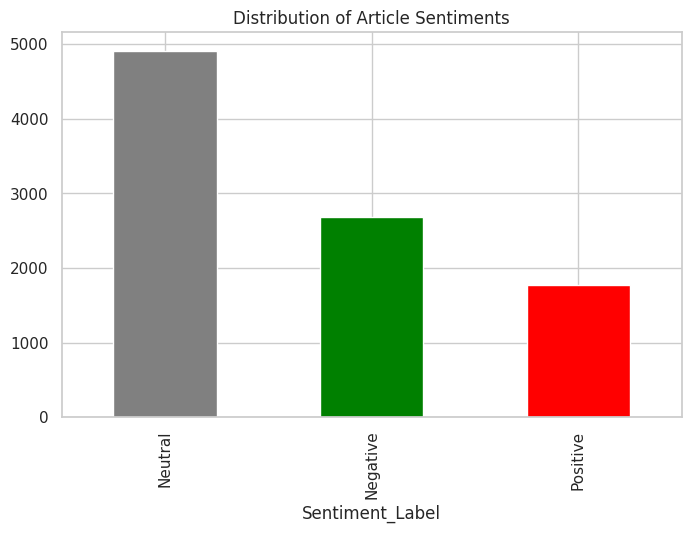

,count
Sentiment_Label,
Neutral,4915
Negative,2682
Positive,1776


In [ ]:
sentiment_dist = df['Sentiment_Label'].value_counts()
plt.figure(figsize=(8, 5))
sentiment_dist.plot(kind='bar', color=['gray', 'green', 'red'])
plt.title('Distribution of Article Sentiments')
plt.show()
display(sentiment_dist)

###Comparing FinBERT with GDELT V2Tone


Correlation: 0.3227


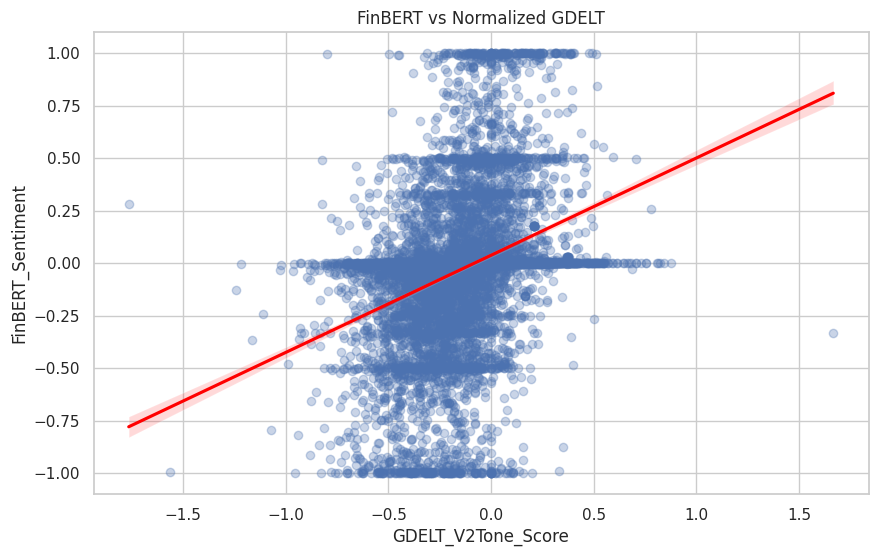

In [ ]:
def extract_and_normalize_v2tone(tone_str):
    try:
        raw_score = float(tone_str.split(',')[0])
        return raw_score / 10.0
    except:
        return 0.0

df['GDELT_V2Tone_Score'] = df['V2Tone'].apply(extract_and_normalize_v2tone)
correlation = df['FinBERT_Sentiment'].corr(df['GDELT_V2Tone_Score'])
print(f'Correlation: {correlation:.4f}')

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='GDELT_V2Tone_Score', y='FinBERT_Sentiment', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('FinBERT vs Normalized GDELT')
plt.show()

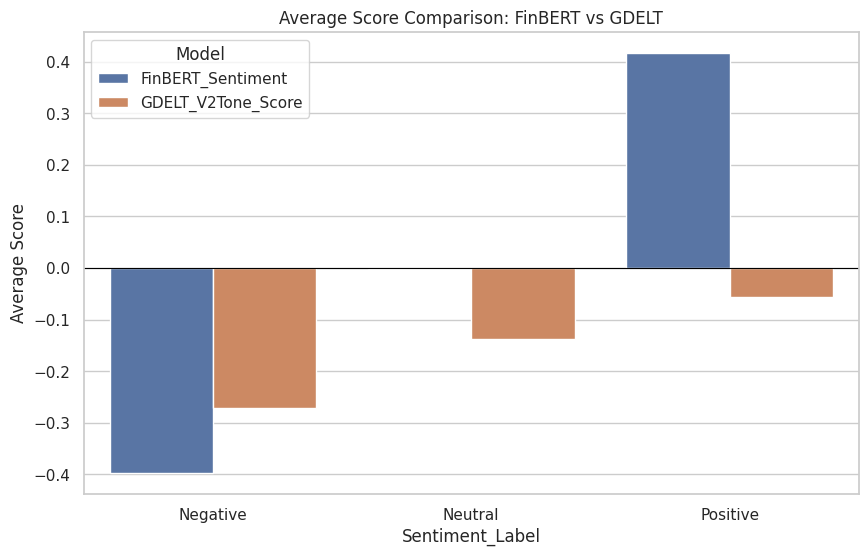

,FinBERT_Sentiment,GDELT_V2Tone_Score
Sentiment_Label,,
Negative,-0.397435,-0.270509
Neutral,-0.002071,-0.137340
Positive,0.416918,-0.056033


In [ ]:
# Group and calculate means for static plotting
comparison_cols = df.groupby('Sentiment_Label')[['FinBERT_Sentiment', 'GDELT_V2Tone_Score']].mean().reset_index()

# Reshape data for seaborn
comparison_melted = comparison_cols.melt(id_vars='Sentiment_Label', var_name='Model', value_name='Average Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_melted, x='Sentiment_Label', y='Average Score', hue='Model')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Score Comparison: FinBERT vs GDELT')
plt.show()

display(comparison_cols.set_index('Sentiment_Label'))

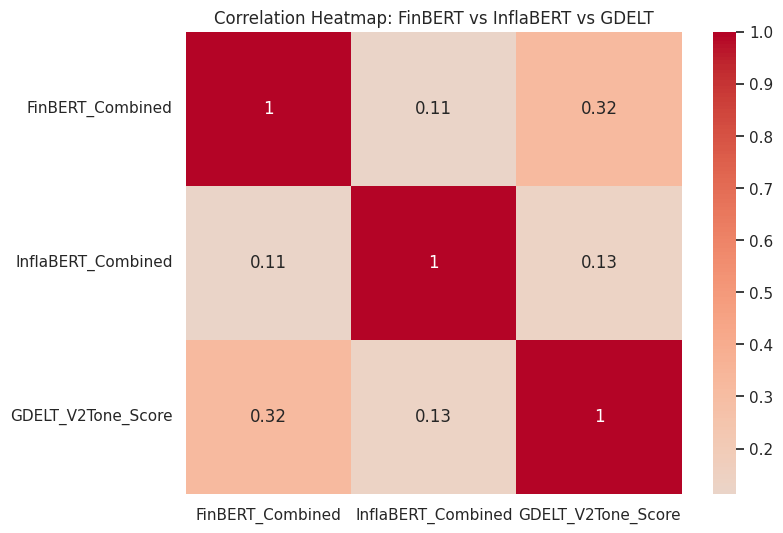

,FinBERT_Combined,InflaBERT_Combined,GDELT_V2Tone_Score
FinBERT_Combined,1.000000,0.113632,0.318793
InflaBERT_Combined,0.113632,1.000000,0.130680
GDELT_V2Tone_Score,0.318793,0.130680,1.000000


In [23]:
def extract_v2tone(tone_str):
    try:
        return float(tone_str.split(',')[0]) / 10.0
    except:
        return 0.0

# Ensure the GDELT column exists before correlating
df['GDELT_V2Tone_Score'] = df['V2Tone'].apply(extract_v2tone)

model_corr = df[['FinBERT_Combined', 'InflaBERT_Combined', 'GDELT_V2Tone_Score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(model_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: FinBERT vs InflaBERT vs GDELT')
plt.show()

display(model_corr)

### Comparing Predictive Power: InflaBERT vs FinBERT
We will now generate a monthly InflaBERT index and compare its ability to 'Granger-cause' inflation relative to the general FinBERT index.

In [33]:
import pandas as pd

cpi_clean_path = '/content/drive/MyDrive/UK_CPI_2024_2026_clean.csv'

try:
    # Load the CSV file
    cpi_df = pd.read_csv(cpi_clean_path)

    # Display basic info and the first few rows
    print(f"Dataset shape: {cpi_df.shape}")
    display(cpi_df.head())
    display(cpi_df.info())
except Exception as e:
    print(f"Error loading file: {e}")

Dataset shape: (28, 10)


,Date,Month,Year,Month Name,CPI Index (2015=100),ONS 12-month % change,ONS 1-month % change,Log CPI,Log MoM inflation %,Log YoY inflation %
0,1/1/2024,2024-01,2024,Jan,131.5,4.0,-0.6,4.879007,NaN,NaN
1,2/1/2024,2024-02,2024,Feb,132.3,3.4,0.6,4.885072,0.607,NaN
2,3/1/2024,2024-03,2024,Mar,133.0,3.2,0.6,4.890349,0.528,NaN
3,4/1/2024,2024-04,2024,Apr,133.5,2.3,0.3,4.894101,0.375,NaN
4,5/1/2024,2024-05,2024,May,133.9,2.0,0.3,4.897093,0.299,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   28 non-null     object 
 1   Month                  28 non-null     object 
 2   Year                   28 non-null     int64  
 3   Month Name             28 non-null     object 
 4   CPI Index (2015=100)   28 non-null     float64
 5   ONS 12-month % change  28 non-null     float64
 6   ONS 1-month % change   26 non-null     float64
 7   Log CPI                28 non-null     float64
 8   Log MoM inflation %    27 non-null     float64
 9   Log YoY inflation %    16 non-null     float64
dtypes: float64(6), int64(1), object(3)
memory usage: 2.3+ KB


None

In [32]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Update path and load CSV
cpi_clean_path = '/content/drive/MyDrive/UK_CPI_2024_2026_clean.csv'
try:
    raw_df = pd.read_csv(cpi_clean_path)

    # Setup Columns
    cpi_col, date_col = 'CPI Index (2015=100)', 'Date'
    raw_df[cpi_col] = pd.to_numeric(raw_df[cpi_col], errors='coerce')
    raw_df[date_col] = pd.to_datetime(raw_df[date_col], errors='coerce')
    raw_df = raw_df.dropna(subset=[date_col, cpi_col])

    # Filter for 2024-2025 only (2 years) as requested
    raw_df = raw_df[(raw_df[date_col].dt.year >= 2024) & (raw_df[date_col].dt.year <= 2025)].copy()
    raw_df = raw_df.sort_values(date_col)

    # Calculate log difference WITHIN the 2024-2025 window
    raw_df['Log_CPI'] = np.log(raw_df[cpi_col])
    raw_df['Inflation_Rate'] = raw_df['Log_CPI'].diff() * 100
    raw_df['Month_Key'] = raw_df[date_col].dt.strftime('%Y-%m')

    # 2. Prepare Sentiment from existing df for the same period
    df['ArticleDate'] = pd.to_datetime(df['ArticleDate'])
    df_subset = df[(df['ArticleDate'].dt.year >= 2024) & (df['ArticleDate'].dt.year <= 2025)].copy()
    df_subset['Month'] = df_subset['ArticleDate'].dt.to_period('M')

    ms = df_subset.groupby('Month')[['FinBERT_Combined', 'InflaBERT_Combined']].mean().reset_index()
    ms['Month_Key'] = ms['Month'].astype(str)

    # 3. Merge
    analysis_df = pd.merge(ms, raw_df[['Month_Key', 'Inflation_Rate']], on='Month_Key', how='inner')
    analysis_df = analysis_df.dropna()

    # Standardize indicators for this specific 2-year threshold
    for col in ['FinBERT_Combined', 'InflaBERT_Combined']:
        analysis_df[f'{col}_Std'] = (analysis_df[col] - analysis_df[col].mean()) / analysis_df[col].std()

    # Prepare Lags
    analysis_df['Inf_Lag1'] = analysis_df['Inflation_Rate'].shift(1)
    analysis_df['Fin_Lag1'] = analysis_df['FinBERT_Combined_Std'].shift(1)
    analysis_df['Infla_Lag1'] = analysis_df['InflaBERT_Combined_Std'].shift(1)
    comp_df = analysis_df.dropna()

    def fit_adl(feature):
        X = sm.add_constant(comp_df[['Inf_Lag1', feature]])
        return sm.OLS(comp_df['Inflation_Rate'], X).fit()

    res_fin = fit_adl('Fin_Lag1')
    res_inf = fit_adl('Infla_Lag1')

    print("--- 2024-2025 Predictive Comparison (2-Year Threshold) ---")
    print(f"FinBERT Combined  | R2: {res_fin.rsquared:.4f} | AIC: {res_fin.aic:.4f} | P-val (Lag): {res_fin.pvalues.iloc[-1]:.4f}")
    print(f"InflaBERT Combined | R2: {res_inf.rsquared:.4f} | AIC: {res_inf.aic:.4f} | P-val (Lag): {res_inf.pvalues.iloc[-1]:.4f}")

except Exception as e:
    print(f"Error rebuilding analysis: {e}")

--- 2024-2025 Predictive Comparison (2-Year Threshold) ---
FinBERT Combined  | R2: 0.1571 | AIC: 13.7629 | P-val (Lag): 0.1060
InflaBERT Combined | R2: 0.0489 | AIC: 16.4191 | P-val (Lag): 0.5393


### Live Data Retrieval from ONS
Instead of a static CSV, we can pull the 'Consumer Price Inflation time series' (MM23) directly from the ONS. Series **D7BT** corresponds to the CPI Index (2015=100).

In [43]:
import requests
import pandas as pd
import numpy as np
from io import StringIO

def get_live_uk_cpi():
    # ONS URL for the CPI All Items Index (Series ID: D7BT)
    url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/inflationandpriceindices/timeseries/d7bt/mm23"

    try:
        # Download the CSV directly
        response = requests.get(url)
        response.raise_for_status()

        data = StringIO(response.text)

        # ONS CSVs have metadata in the first few rows
        live_df = pd.read_csv(data, skiprows=8, names=['Date', 'CPI_Index'])

        # Filter for monthly data (e.g., '2024 JAN')
        live_df = live_df[live_df['Date'].str.contains(r'\d{4} [A-Z]{3}', na=False)].copy()

        # Convert Date and Numeric Index
        live_df['Date'] = pd.to_datetime(live_df['Date'], format='%Y %b')
        live_df['CPI_Index'] = pd.to_numeric(live_df['CPI_Index'])

        # Filter for 2024-2025
        live_df = live_df[(live_df['Date'].dt.year >= 2024) & (live_df['Date'].dt.year <= 2025)]
        live_df = live_df.sort_values('Date')

        # Calculate Inflation Rate
        live_df['Inflation_Rate_Live'] = np.log(live_df['CPI_Index']).diff() * 100
        live_df['Month_Key'] = live_df['Date'].dt.strftime('%Y-%m')

        return live_df.dropna()

    except Exception as e:
        print(f"Failed to fetch online data: {e}")
        return None

online_cpi = get_live_uk_cpi()
if online_cpi is not None:
    display(online_cpi.head())
    print("\nOnline CPI data successfully retrieved and processed.")

,Date,CPI_Index,Inflation_Rate_Live,Month_Key
624,2024-02-01,132.3,0.606522,2024-02
625,2024-03-01,133.0,0.527706,2024-03
626,2024-04-01,133.5,0.375235,2024-04
627,2024-05-01,133.9,0.299177,2024-05
628,2024-06-01,134.1,0.149254,2024-06



Online CPI data successfully retrieved and processed.


In [39]:
# 1. Apply Log Transformation and First Difference to the live CPI data
# We start from 'online_cpi' which was recently fetched from ONS

if online_cpi is not None:
    # Ensure data is sorted by date for correct differencing
    online_cpi = online_cpi.sort_values('Date')

    # Calculate Log CPI levels
    online_cpi['Log_CPI'] = np.log(online_cpi['CPI_Index'])

    # Calculate First Log Difference (Inflation Rate)
    # We multiply by 100 to represent the percentage change
    online_cpi['Inflation_Rate_LogDiff'] = online_cpi['Log_CPI'].diff() * 100

    print("--- Live CPI Transformation (Log First Difference) ---")
    display(online_cpi[['Date', 'CPI_Index', 'Log_CPI', 'Inflation_Rate_LogDiff']].head())
else:
    print("Error: Live CPI data 'online_cpi' is not available in the kernel.")

--- Live CPI Transformation (Log First Difference) ---


,Date,CPI_Index,Log_CPI,Inflation_Rate_LogDiff
624,2024-02-01,132.3,4.885072,NaN
625,2024-03-01,133.0,4.890349,0.527706
626,2024-04-01,133.5,4.894101,0.375235
627,2024-05-01,133.9,4.897093,0.299177
628,2024-06-01,134.1,4.898586,0.149254


In [47]:
import statsmodels.api as sm
import numpy as np
import requests
from io import StringIO

# 1. Fetch wider range for ONS data to provide lags for 2024
def get_buffered_cpi():
    url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/inflationandpriceindices/timeseries/d7bt/mm23"
    response = requests.get(url)
    data = StringIO(response.text)
    live_df = pd.read_csv(data, skiprows=8, names=['Date', 'CPI_Index'])
    live_df = live_df[live_df['Date'].str.contains(r'\d{4} [A-Z]{3}', na=False)].copy()
    live_df['Date'] = pd.to_datetime(live_df['Date'], format='%Y %b')
    live_df['CPI_Index'] = pd.to_numeric(live_df['CPI_Index'])
    # Buffer: Start from late 2023 to enable 2024 calculations
    live_df = live_df[(live_df['Date'] >= '2023-10-01') & (live_df['Date'] <= '2025-12-31')]
    live_df = live_df.sort_values('Date')
    live_df['Inflation_Rate_LogDiff'] = np.log(live_df['CPI_Index']).diff() * 100
    live_df['Month_Key'] = live_df['Date'].dt.strftime('%Y-%m')
    return live_df

buffered_cpi = get_buffered_cpi()

# 2. Prepare Sentiment with 2023 buffer
df['Month_Key'] = df['ArticleDate'].dt.strftime('%Y-%m')
monthly_sentiment_live = df.groupby('Month_Key')[['FinBERT_Combined', 'InflaBERT_Combined']].mean().reset_index()

# Standardize
for col in ['FinBERT_Combined', 'InflaBERT_Combined']:
    mu, sigma = monthly_sentiment_live[col].mean(), monthly_sentiment_live[col].std()
    monthly_sentiment_live[f'{col}_Std'] = (monthly_sentiment_live[col] - mu) / sigma

# 3. Merge and Lag
live_analysis_df = pd.merge(monthly_sentiment_live, buffered_cpi[['Month_Key', 'Inflation_Rate_LogDiff']], on='Month_Key', how='inner')
live_analysis_df['Inf_Lag1'] = live_analysis_df['Inflation_Rate_LogDiff'].shift(1)
live_analysis_df['Fin_Lag1'] = live_analysis_df['FinBERT_Combined_Std'].shift(1)
live_analysis_df['Infla_Lag1'] = live_analysis_df['InflaBERT_Combined_Std'].shift(1)

# 4. Filter for target window (2024-2025) AFTER lagging
live_comp_df = live_analysis_df[(live_analysis_df['Month_Key'] >= '2024-01') & (live_analysis_df['Month_Key'] <= '2025-12')].dropna()

# 5. Execute Models
def run_live_adl(feature_col):
    X = sm.add_constant(live_comp_df[['Inf_Lag1', feature_col]])
    y = live_comp_df['Inflation_Rate_LogDiff']
    return sm.OLS(y, X).fit()

res_fin_live = run_live_adl('Fin_Lag1')
res_inf_live = run_live_adl('Infla_Lag1')

print(f"--- Full Window Analysis (Months: {len(live_comp_df)}) ---")
print(f"FinBERT R2: {res_fin_live.rsquared:.4f} | P-val: {res_fin_live.pvalues.iloc[-1]:.4f}")
display(live_comp_df.head())

--- Full Window Analysis (Months: 24) ---
FinBERT R2: 0.1094 | P-val: 0.3344


,Month_Key,FinBERT_Combined,InflaBERT_Combined,FinBERT_Combined_Std,InflaBERT_Combined_Std,Inflation_Rate_LogDiff,Inf_Lag1,Fin_Lag1,Infla_Lag1
3,2024-01,-0.030593,0.200036,0.289143,-0.103445,-0.530908,0.378932,-1.063618,-0.586569
4,2024-02,-0.035375,0.222001,0.157577,0.087393,0.606522,-0.530908,0.289143,-0.103445
5,2024-03,-0.029197,0.287100,0.327552,0.652975,0.527706,0.606522,0.157577,0.087393
6,2024-04,-0.027670,0.215191,0.369560,0.028229,0.375235,0.527706,0.327552,0.652975
7,2024-05,0.001065,0.326778,1.160064,0.997692,0.299177,0.375235,0.369560,0.028229


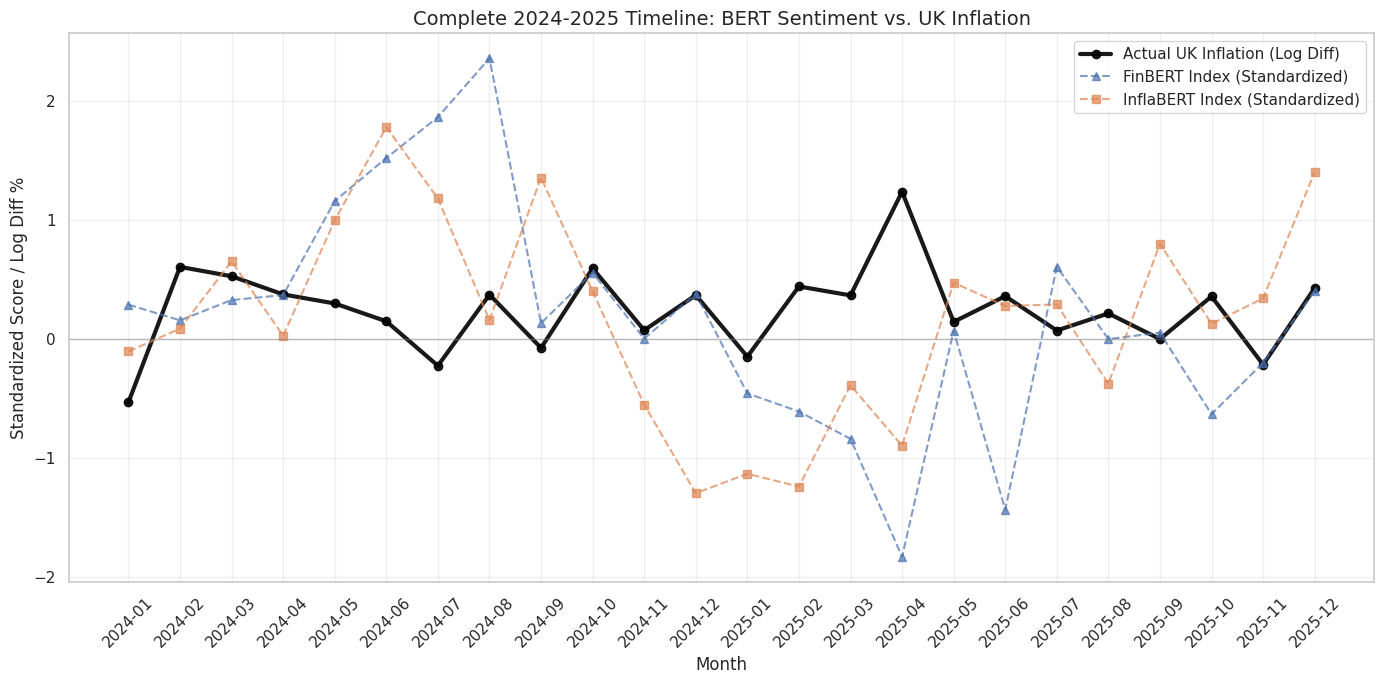

Timeline validation: Data starts at 2024-01 and ends at 2025-12.


In [48]:
import matplotlib.pyplot as plt

# Visualization for the full, buffered 2024-2025 window
plt.figure(figsize=(14, 7))

# Plot Actual Inflation Rate
plt.plot(live_comp_df['Month_Key'], live_comp_df['Inflation_Rate_LogDiff'],
         color='black', linewidth=3, label='Actual UK Inflation (Log Diff)', marker='o', alpha=0.9)

# Plot Standardized BERT Indicators
plt.plot(live_comp_df['Month_Key'], live_comp_df['FinBERT_Combined_Std'],
         label='FinBERT Index (Standardized)', linestyle='--', marker='^', alpha=0.7)
plt.plot(live_comp_df['Month_Key'], live_comp_df['InflaBERT_Combined_Std'],
         label='InflaBERT Index (Standardized)', linestyle='--', marker='s', alpha=0.7)

plt.title('Complete 2024-2025 Timeline: BERT Sentiment vs. UK Inflation', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Standardized Score / Log Diff %', fontsize=12)
plt.axhline(0, color='gray', linewidth=1, alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Timeline validation: Data starts at {live_comp_df['Month_Key'].min()} and ends at {live_comp_df['Month_Key'].max()}.")

In [49]:
from sklearn.metrics import mean_squared_error

# 1. Baseline AR(1) model for comparison
X_base = sm.add_constant(live_comp_df['Inf_Lag1'])
y_true = live_comp_df['Inflation_Rate_LogDiff']
res_base = sm.OLS(y_true, X_base).fit()

# 2. Calculate RMSE for all models
rmse_base = np.sqrt(mean_squared_error(y_true, res_base.predict(X_base)))
rmse_fin = np.sqrt(mean_squared_error(y_true, res_fin_live.predict(sm.add_constant(live_comp_df[['Inf_Lag1', 'Fin_Lag1']]))))
rmse_infla = np.sqrt(mean_squared_error(y_true, res_inf_live.predict(sm.add_constant(live_comp_df[['Inf_Lag1', 'Infla_Lag1']]))))

# 3. Improvement over baseline
improvement = (1 - (rmse_fin / rmse_base)) * 100

print("--- Forecast Accuracy Comparison (RMSE) ---")
print(f"Baseline AR(1) RMSE:  {rmse_base:.4f}")
print(f"FinBERT ADL RMSE:    {rmse_fin:.4f}")
print(f"InflaBERT ADL RMSE:  {rmse_infla:.4f}")
print(f"\nFinBERT Improvement over Baseline: {improvement:.2f}%")

--- Forecast Accuracy Comparison (RMSE) ---
Baseline AR(1) RMSE:  0.3363
FinBERT ADL RMSE:    0.3288
InflaBERT ADL RMSE:  0.3355

FinBERT Improvement over Baseline: 2.25%


### Investigating Data Influence on Sentiment Spikes
We are analyzing if specific themes or article volumes within our GDELT dataset correlate with the major sentiment swings observed in the timeline.

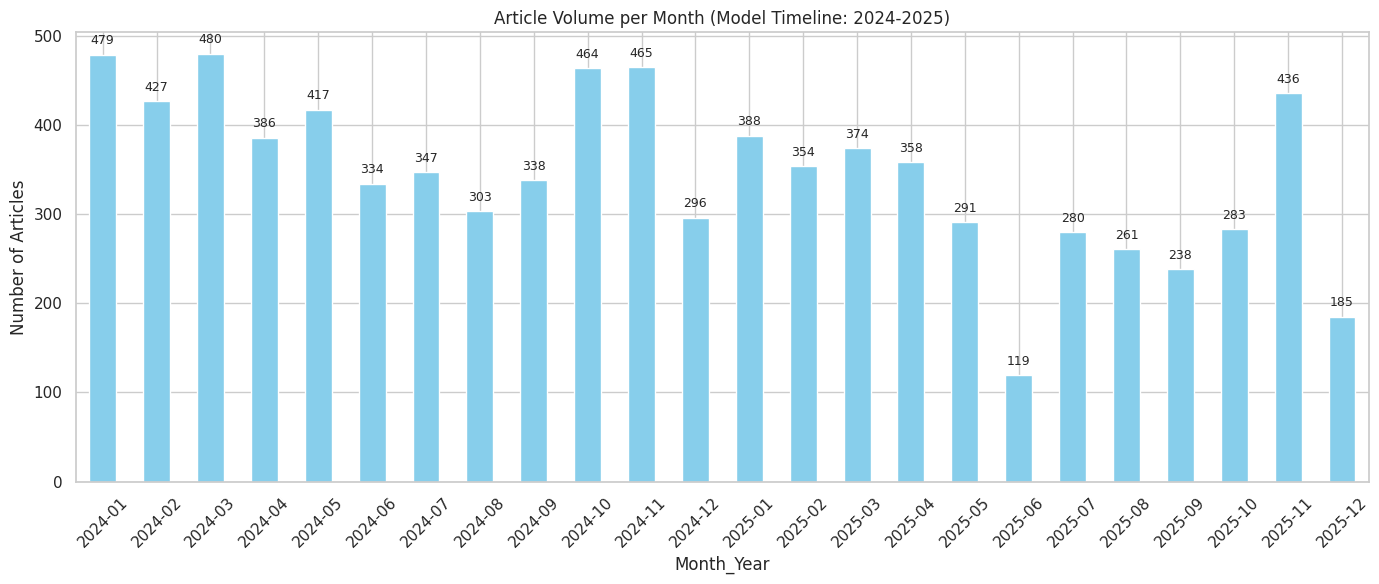


Top Themes during Upward Spike (Apr-Aug 2024):
 USPEC_POLICY1                                   4421
TAX_ECON_PRICE                                  4240
EPU_POLICY_TAX                                  3514
ECON_TAXATION                                   3416
WB_1104_MACROECONOMIC_VULNERABILITY_AND_DEBT    3360
GENERAL_GOVERNMENT                              3205
EPU_POLICY_GOVERNMENT                           3172
EPU_CATS_TAXES                                  3093
WB_442_INFLATION                                2985
ECON_INFLATION                                  2953
Name: count, dtype: int64

Top Themes during Downward Dip (Dec 2024-Jun 2025):
 USPEC_POLICY1                                   6739
TAX_ECON_PRICE                                  5325
EPU_POLICY_GOVERNMENT                           4938
EPU_POLICY_TAX                                  4868
ECON_TAXATION                                   4857
GENERAL_GOVERNMENT                              4830
EPU_CATS_TAXES         

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter dataframe to match the ADL model timeline (2024-01 to 2025-12)
df_filtered = df[(df['ArticleDate'] >= '2024-01-01') & (df['ArticleDate'] <= '2025-12-31')].copy()

# Define the windows of interest within this specific range
spike_window = (df_filtered['ArticleDate'] >= '2024-04-01') & (df_filtered['ArticleDate'] <= '2024-08-31')
dip_window = (df_filtered['ArticleDate'] >= '2024-12-01') & (df_filtered['ArticleDate'] <= '2025-06-30')

# 1. Check Article Volume for the exact model timeline
df_filtered['Month_Year'] = df_filtered['ArticleDate'].dt.to_period('M')
volume_counts = df_filtered['Month_Year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
ax = volume_counts.plot(kind='bar', color='skyblue')

# Annotate counts on top of bars
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=9)

plt.title('Article Volume per Month (Model Timeline: 2024-2025)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Extract Top Themes for the target windows
def get_top_themes(mask, title):
    themes_series = df_filtered[mask]['V2Themes'].dropna().str.split(';')
    flat_themes = [item.split(',')[0] for sublist in themes_series for item in sublist if item]
    top_themes = pd.Series(flat_themes).value_counts().head(10)
    print(f"\nTop Themes during {title}:\n", top_themes)

get_top_themes(spike_window, "Upward Spike (Apr-Aug 2024)")
get_top_themes(dip_window, "Downward Dip (Dec 2024-Jun 2025)")

### Final Comparison: Balanced vs. Unbalanced Signal
We overlay both indices to see if the 'spikes' in the original data were real trends or just artifacts of sample size.

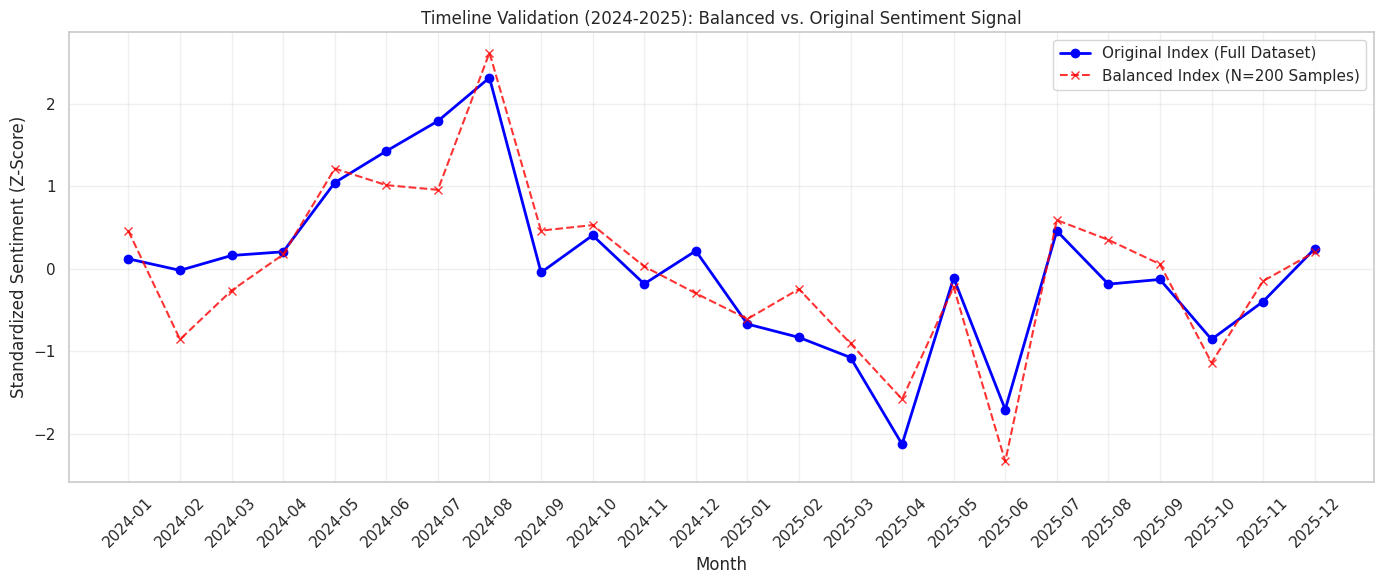

Correlation between indices in this window: 0.9101


In [59]:
plt.figure(figsize=(14, 6))

# 1. Prepare Original (Full) Monthly Data for the model timeline
monthly_original = df.groupby('Month_Key')['FinBERT_Combined'].mean().reset_index()
# Filter for 2024-2025
monthly_original = monthly_original[(monthly_original['Month_Key'] >= '2024-01') & (monthly_original['Month_Key'] <= '2025-12')]
# Standardize
mu_o, std_o = monthly_original['FinBERT_Combined'].mean(), monthly_original['FinBERT_Combined'].std()
monthly_original['FinBERT_Std_Original'] = (monthly_original['FinBERT_Combined'] - mu_o) / std_o

# 2. Filter Balanced Data for the same timeline
monthly_balanced_filt = monthly_balanced[(monthly_balanced['Month_Key'] >= '2024-01') & (monthly_balanced['Month_Key'] <= '2025-12')].copy()
# Standardize
mu_b, std_b = monthly_balanced_filt['FinBERT_Combined'].mean(), monthly_balanced_filt['FinBERT_Combined'].std()
monthly_balanced_filt['FinBERT_Std_Balanced'] = (monthly_balanced_filt['FinBERT_Combined'] - mu_b) / std_b

# 3. Plot
plt.plot(monthly_original['Month_Key'], monthly_original['FinBERT_Std_Original'],
         label='Original Index (Full Dataset)', color='blue', linewidth=2, marker='o')
plt.plot(monthly_balanced_filt['Month_Key'], monthly_balanced_filt['FinBERT_Std_Balanced'],
         label='Balanced Index (N=200 Samples)', color='red', linestyle='--', marker='x', alpha=0.8)

plt.title('Timeline Validation (2024-2025): Balanced vs. Original Sentiment Signal')
plt.ylabel('Standardized Sentiment (Z-Score)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation between indices in this window: {monthly_original['FinBERT_Std_Original'].corr(monthly_balanced_filt['FinBERT_Std_Balanced']):.4f}")